# Community voting vs. moderator decisions

This notebook asks:

> **How well do community-vote rules, Community-Notes-style latent-viewpoint scoring, and supervised machine-learning models recover moderator approval/removal decisions?**

The analysis is intentionally **non-temporal**. `created_utc` is not used.

## Required CSVs

**Moderation CSV**
- `post_id`
- `status` (`approved` / `removed`)

**Votes CSV**
- `author`
- `post_id`
- `vote` (`upvote` / `downvote`)
- `subreddit`

Extra columns are ignored.

## Outcome coding

- moderator `removed = 1`, `approved = 0`
- community `downvote = 1`, `upvote = 0`

The final evaluation reports performance separately for:

1. **removed posts**
2. **approved posts**
3. **combined performance**

## 1. Imports and configuration

In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
)

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "xgboost is required for the XGBoost baseline. "
        "Install it with `%pip install xgboost` and rerun the notebook."
    ) from e

import torch
import torch.nn as nn


# ============================================================
# CHANGE THESE TWO PATHS
# ============================================================

MODERATION_CSV = "moderation_status.csv"
VOTES_CSV = "votes.csv"


# Eligibility
MIN_USER_TOTAL_VOTES = 10
MIN_POST_VOTES = 5

# Random post split
TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
# Remaining 20% is test.

# Matrix factorization
LAMBDA_INTERCEPT = 0.15
LAMBDA_FACTOR = 0.03

BIAS_EPOCHS = 20
MF_EPOCHS = 30
BATCH_SIZE = 131_072
LEARNING_RATE = 0.03

# WNet subreddit threshold
MIN_SUBREDDIT_VAL_POSTS = 20

# Supervised ML
RIDGE_ALPHA = 1.0

GB_MAX_ITER = 200
GB_LEARNING_RATE = 0.08
GB_MAX_LEAF_NODES = 31

XGB_N_ESTIMATORS = 300
XGB_MAX_DEPTH = 6
XGB_LEARNING_RATE = 0.05

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Torch device:", DEVICE)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-09ijkkfc because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Torch device: cpu


## 2. Read the CSV files

Only the columns needed for this analysis are loaded. This avoids loading timestamp and index columns from the very large vote file.

In [2]:
moderation_status = pd.read_csv(
    MODERATION_CSV,
    usecols=["post_id", "status"],
    dtype={
        "post_id": "string",
        "status": "string",
    },
)

votes = pd.read_csv(
    VOTES_CSV,
    usecols=["author", "post_id", "vote", "subreddit"],
    dtype={
        "author": "string",
        "post_id": "string",
        "vote": "string",
        "subreddit": "string",
    },
)

print("moderation_status:", moderation_status.shape)
print("votes:", votes.shape)

display(moderation_status.head())
display(votes.head())

moderation_status: (360, 2)
votes: (10080, 4)


,post_id,status
0,p0,approved
1,p1,removed
2,p2,approved
3,p3,approved
4,p4,approved


,author,post_id,vote,subreddit
0,u97,p0,downvote,r/sub5
1,u33,p0,downvote,r/sub5
2,u10,p0,downvote,r/sub5
3,u53,p0,downvote,r/sub5
4,u25,p0,downvote,r/sub5


## 3. Clean and match the data

In [3]:
mod = moderation_status.copy()
v = votes.copy()

mod["status"] = mod["status"].str.lower().str.strip()
v["vote"] = v["vote"].str.lower().str.strip()
v["subreddit"] = v["subreddit"].str.strip()

STATUS_MAP = {
    "approved": 0,
    "approve": 0,
    "removed": 1,
    "remove": 1,
}

VOTE_MAP = {
    "upvote": 0.0,
    "downvote": 1.0,
}

print("Moderation labels before filtering:")
display(mod["status"].value_counts(dropna=False).head(20).to_frame("n"))

print("Vote labels before filtering:")
display(v["vote"].value_counts(dropna=False).head(20).to_frame("n"))

mod = mod[mod["status"].isin(STATUS_MAP)].copy()
v = v[v["vote"].isin(VOTE_MAP)].copy()

mod["removed"] = mod["status"].map(STATUS_MAP).astype("int8")
mod["status"] = np.where(mod["removed"].eq(1), "removed", "approved")

v["y_vote"] = v["vote"].map(VOTE_MAP).astype("float32")

mod = mod.dropna(subset=["post_id"]).copy()
v = v.dropna(subset=["author", "post_id"]).copy()

mod["post_id"] = mod["post_id"].str.strip()
v["post_id"] = v["post_id"].str.strip()
v["author"] = v["author"].str.strip()

mod = mod[mod["post_id"].ne("")].copy()
v = v[v["post_id"].ne("") & v["author"].ne("")].copy()

# Missing subreddit gets a stable fallback label.
v["subreddit"] = v["subreddit"].fillna("UNKNOWN")
v.loc[v["subreddit"].eq(""), "subreddit"] = "UNKNOWN"

# One moderator outcome per post.
mod = (
    mod.drop_duplicates("post_id", keep="last")
       .reset_index(drop=True)
)

# Check ID overlap before merging.
mod_ids = pd.Index(mod["post_id"].unique())
vote_ids = pd.Index(v["post_id"].unique())
n_overlap = len(mod_ids.intersection(vote_ids))

print(f"Moderator post IDs: {len(mod_ids):,}")
print(f"Vote post IDs:      {len(vote_ids):,}")
print(f"Overlapping IDs:    {n_overlap:,}")

if n_overlap == 0:
    raise ValueError(
        "There is no overlap between moderation_status.post_id and votes.post_id."
    )

# One vote per author-post pair.
# Because this notebook intentionally ignores time, the final row in dataframe
# order is retained if duplicates exist.
v = (
    v.drop_duplicates(["author", "post_id"], keep="last")
     .reset_index(drop=True)
)

# Attach moderator outcome.
v = v.merge(
    mod[["post_id", "status", "removed"]],
    on="post_id",
    how="inner",
    validate="many_to_one",
)

# A Reddit post should belong to one subreddit. Take the first observed subreddit
# for the post after cleaning.
post_subreddit = (
    v[["post_id", "subreddit"]]
    .drop_duplicates("post_id", keep="first")
    .reset_index(drop=True)
)

print("\nClean matched data:")
print("Moderator posts:", f"{mod['post_id'].nunique():,}")
print("Posts with votes + moderator outcome:", f"{v['post_id'].nunique():,}")
print("Unique author-post votes:", f"{len(v):,}")
print("Unique voters:", f"{v['author'].nunique():,}")
print("Subreddits:", f"{post_subreddit['subreddit'].nunique():,}")

if v.empty:
    raise RuntimeError("No votes remain after cleaning and matching.")

Moderation labels before filtering:


,n
status,
approved,282
removed,78


Vote labels before filtering:


,n
vote,
upvote,5262
downvote,4818


Moderator post IDs: 360
Vote post IDs:      360
Overlapping IDs:    360

Clean matched data:
Moderator posts: 360
Posts with votes + moderator outcome: 360
Unique author-post votes: 10,080
Unique voters: 140
Subreddits: 8


## 4. Apply the ≥10-votes-per-user and ≥5-votes-per-post rules

Users are filtered first. Post vote counts are then recalculated using only those eligible users.

In [4]:
user_counts = v.groupby("author", sort=False).size()

eligible_users = user_counts[
    user_counts >= MIN_USER_TOTAL_VOTES
].index

v_eligible = v[
    v["author"].isin(eligible_users)
].copy()

post_counts = v_eligible.groupby("post_id", sort=False).size()

eligible_posts = post_counts[
    post_counts >= MIN_POST_VOTES
].index

v_eligible = v_eligible[
    v_eligible["post_id"].isin(eligible_posts)
].copy()

mod_eligible = mod[
    mod["post_id"].isin(eligible_posts)
].copy()

post_subreddit_eligible = post_subreddit[
    post_subreddit["post_id"].isin(eligible_posts)
].copy()

print("Eligible voters:", f"{v_eligible['author'].nunique():,}")
print("Eligible posts:", f"{v_eligible['post_id'].nunique():,}")
print("Eligible votes:", f"{len(v_eligible):,}")

print("\nModerator outcomes among eligible posts:")
class_summary = (
    mod_eligible["status"]
    .value_counts()
    .rename("n")
    .to_frame()
)
class_summary["proportion"] = class_summary["n"] / class_summary["n"].sum()
display(class_summary)

if v_eligible.empty:
    raise RuntimeError("No data remain after eligibility filtering.")

Eligible voters: 140
Eligible posts: 360
Eligible votes: 10,080

Moderator outcomes among eligible posts:


,n,proportion
status,,
approved,282,0.783333
removed,78,0.216667


## 5. Stratified random post split

In [5]:
def make_post_split(
    mod_df,
    train_frac=0.60,
    val_frac=0.20,
    random_state=42,
):
    posts = (
        mod_df[["post_id", "removed", "status"]]
        .drop_duplicates("post_id")
        .reset_index(drop=True)
    )

    test_frac = 1.0 - train_frac - val_frac

    train_posts, remaining = train_test_split(
        posts,
        test_size=val_frac + test_frac,
        stratify=posts["removed"],
        random_state=random_state,
    )

    relative_test_frac = test_frac / (val_frac + test_frac)

    val_posts, test_posts = train_test_split(
        remaining,
        test_size=relative_test_frac,
        stratify=remaining["removed"],
        random_state=random_state,
    )

    train_posts = train_posts.copy()
    val_posts = val_posts.copy()
    test_posts = test_posts.copy()

    train_posts["split"] = "train"
    val_posts["split"] = "val"
    test_posts["split"] = "test"

    return pd.concat(
        [train_posts, val_posts, test_posts],
        ignore_index=True,
    )


post_split = make_post_split(
    mod_eligible,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    random_state=SEED,
)

display(
    pd.crosstab(
        post_split["split"],
        post_split["status"],
        margins=True,
    )
)

display(
    pd.crosstab(
        post_split["split"],
        post_split["status"],
        normalize="index",
    ).round(4)
)

status,approved,removed,All
split,,,
test,57,15,72
train,169,47,216
val,56,16,72
All,282,78,360


status,approved,removed
split,,
test,0.7917,0.2083
train,0.7824,0.2176
val,0.7778,0.2222


## 6. Build and encode the training voting graph

Only training-post votes are used to learn user intercepts and latent viewpoints.

In [6]:
train_post_ids = set(
    post_split.loc[
        post_split["split"] == "train",
        "post_id",
    ]
)

train_votes = v_eligible[
    v_eligible["post_id"].isin(train_post_ids)
].copy()

# Retain training posts with at least the required number of usable votes.
train_counts = train_votes.groupby("post_id", sort=False).size()
keep_train_posts = train_counts[
    train_counts >= MIN_POST_VOTES
].index

train_votes = train_votes[
    train_votes["post_id"].isin(keep_train_posts)
].reset_index(drop=True)

print("Training votes:", f"{len(train_votes):,}")
print("Training users:", f"{train_votes['author'].nunique():,}")
print("Training posts:", f"{train_votes['post_id'].nunique():,}")

if train_votes.empty:
    raise RuntimeError("Training graph is empty.")


@dataclass
class EncodedRatings:
    user_idx: np.ndarray
    post_idx: np.ndarray
    y: np.ndarray
    idx_to_user: np.ndarray
    idx_to_post: np.ndarray
    user_counts: np.ndarray
    post_counts: np.ndarray


def encode_ratings(df):
    idx_to_user = df["author"].unique()
    idx_to_post = df["post_id"].unique()

    user_to_idx = {
        user: i for i, user in enumerate(idx_to_user)
    }
    post_to_idx = {
        post: i for i, post in enumerate(idx_to_post)
    }

    user_idx = df["author"].map(user_to_idx).to_numpy(np.int64)
    post_idx = df["post_id"].map(post_to_idx).to_numpy(np.int64)
    y = df["y_vote"].to_numpy(np.float32)

    user_counts = np.bincount(
        user_idx,
        minlength=len(idx_to_user),
    ).astype(np.float32)

    post_counts = np.bincount(
        post_idx,
        minlength=len(idx_to_post),
    ).astype(np.float32)

    return EncodedRatings(
        user_idx=user_idx,
        post_idx=post_idx,
        y=y,
        idx_to_user=idx_to_user,
        idx_to_post=idx_to_post,
        user_counts=user_counts,
        post_counts=post_counts,
    )


enc = encode_ratings(train_votes)

print(
    f"Encoded {len(enc.y):,} votes from "
    f"{len(enc.idx_to_user):,} users on "
    f"{len(enc.idx_to_post):,} posts."
)

Training votes: 6,048
Training users: 140
Training posts: 216
Encoded 6,048 votes from 140 users on 216 posts.


## 7. Bias-only model

\[
\hat r_{up} = \mu + b_u + b_p
\]

In [7]:
class BiasOnlyModel(nn.Module):
    def __init__(self, n_users, n_posts, global_mean):
        super().__init__()

        self.global_intercept = nn.Parameter(
            torch.tensor(float(global_mean), dtype=torch.float32)
        )

        self.user_intercept = nn.Embedding(n_users, 1)
        self.post_intercept = nn.Embedding(n_posts, 1)

        nn.init.zeros_(self.user_intercept.weight)
        nn.init.zeros_(self.post_intercept.weight)

    def forward(self, u, p):
        return (
            self.global_intercept
            + self.user_intercept(u).squeeze(-1)
            + self.post_intercept(p).squeeze(-1)
        )


def fit_bias_only(
    enc,
    epochs=20,
    batch_size=131_072,
    lr=0.03,
    lambda_i=0.15,
):
    n = len(enc.y)

    model = BiasOnlyModel(
        len(enc.idx_to_user),
        len(enc.idx_to_post),
        enc.y.mean(),
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    u_all = torch.from_numpy(enc.user_idx)
    p_all = torch.from_numpy(enc.post_idx)
    y_all = torch.from_numpy(enc.y)

    user_counts_t = torch.from_numpy(enc.user_counts).to(DEVICE)
    post_counts_t = torch.from_numpy(enc.post_counts).to(DEVICE)

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(n)
        squared_error = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]

            u = u_all[idx].to(DEVICE)
            p = p_all[idx].to(DEVICE)
            y = y_all[idx].to(DEVICE)

            pred = model(u, p)

            ui = model.user_intercept(u).squeeze(-1)
            pi = model.post_intercept(p).squeeze(-1)

            reg = lambda_i * (
                (ui ** 2) / user_counts_t[u]
                + (pi ** 2) / post_counts_t[p]
            )

            loss = ((y - pred) ** 2 + reg).mean()

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            squared_error += torch.sum(
                (y - pred).detach() ** 2
            ).item()

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"Bias-only epoch {epoch:>2}/{epochs}: "
                f"RMSE={math.sqrt(squared_error / n):.5f}"
            )

    return model


bias_model = fit_bias_only(
    enc,
    epochs=BIAS_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    lambda_i=LAMBDA_INTERCEPT,
)

Bias-only epoch  1/20: RMSE=0.49884
Bias-only epoch  5/20: RMSE=0.46391
Bias-only epoch 10/20: RMSE=0.45215
Bias-only epoch 15/20: RMSE=0.45019
Bias-only epoch 20/20: RMSE=0.44995


## 8. One-dimensional Community-Notes-style latent-viewpoint model

\[
\hat r_{up}
=
\mu + b_u + b_p + f_u f_p
\]

`user_factor` is the learned latent voting viewpoint.

In [8]:
class OneDimMF(nn.Module):
    def __init__(self, n_users, n_posts, global_mean):
        super().__init__()

        self.global_intercept = nn.Parameter(
            torch.tensor(float(global_mean), dtype=torch.float32)
        )

        self.user_intercept = nn.Embedding(n_users, 1)
        self.post_intercept = nn.Embedding(n_posts, 1)
        self.user_factor = nn.Embedding(n_users, 1)
        self.post_factor = nn.Embedding(n_posts, 1)

        nn.init.zeros_(self.user_intercept.weight)
        nn.init.zeros_(self.post_intercept.weight)

        nn.init.normal_(self.user_factor.weight, mean=0.0, std=0.05)
        nn.init.normal_(self.post_factor.weight, mean=0.0, std=0.05)

    def forward(self, u, p):
        return (
            self.global_intercept
            + self.user_intercept(u).squeeze(-1)
            + self.post_intercept(p).squeeze(-1)
            + self.user_factor(u).squeeze(-1)
              * self.post_factor(p).squeeze(-1)
        )


def fit_one_dim_mf(
    enc,
    epochs=30,
    batch_size=131_072,
    lr=0.03,
    lambda_i=0.15,
    lambda_f=0.03,
):
    n = len(enc.y)

    model = OneDimMF(
        len(enc.idx_to_user),
        len(enc.idx_to_post),
        enc.y.mean(),
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    u_all = torch.from_numpy(enc.user_idx)
    p_all = torch.from_numpy(enc.post_idx)
    y_all = torch.from_numpy(enc.y)

    user_counts_t = torch.from_numpy(enc.user_counts).to(DEVICE)
    post_counts_t = torch.from_numpy(enc.post_counts).to(DEVICE)

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(n)
        squared_error = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]

            u = u_all[idx].to(DEVICE)
            p = p_all[idx].to(DEVICE)
            y = y_all[idx].to(DEVICE)

            pred = model(u, p)

            ui = model.user_intercept(u).squeeze(-1)
            pi = model.post_intercept(p).squeeze(-1)
            uf = model.user_factor(u).squeeze(-1)
            pf = model.post_factor(p).squeeze(-1)

            reg_i = lambda_i * (
                (ui ** 2) / user_counts_t[u]
                + (pi ** 2) / post_counts_t[p]
            )

            reg_f = lambda_f * (
                (uf ** 2) / user_counts_t[u]
                + (pf ** 2) / post_counts_t[p]
            )

            loss = (
                (y - pred) ** 2
                + reg_i
                + reg_f
            ).mean()

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            squared_error += torch.sum(
                (y - pred).detach() ** 2
            ).item()

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"MF epoch {epoch:>2}/{epochs}: "
                f"RMSE={math.sqrt(squared_error / n):.5f}"
            )

    return model


mf_model = fit_one_dim_mf(
    enc,
    epochs=MF_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    lambda_i=LAMBDA_INTERCEPT,
    lambda_f=LAMBDA_FACTOR,
)

MF epoch  1/30: RMSE=0.49885
MF epoch  5/30: RMSE=0.46143
MF epoch 10/30: RMSE=0.44246
MF epoch 15/30: RMSE=0.43463
MF epoch 20/30: RMSE=0.43164
MF epoch 25/30: RMSE=0.42915
MF epoch 30/30: RMSE=0.42709


## 9. Extract learned user parameters

,author,bias_only_user_intercept,mf_user_intercept,user_factor,n_training_votes
0,u97,-0.129269,-0.100370,-0.226936,45
1,u33,0.032738,0.041396,0.597712,49
2,u10,0.088698,0.143432,0.017889,52
3,u53,-0.026640,-0.021650,-0.263495,42
4,u25,-0.117142,-0.104530,-0.277284,35


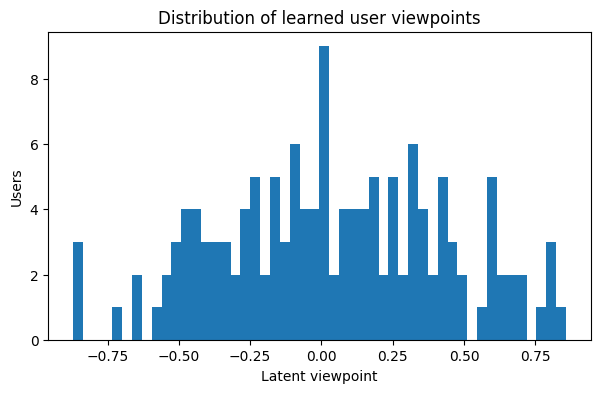

In [9]:
with torch.no_grad():
    user_params = pd.DataFrame({
        "author": enc.idx_to_user,

        "bias_only_user_intercept":
            bias_model.user_intercept.weight
            .detach().cpu().numpy().ravel(),

        "mf_user_intercept":
            mf_model.user_intercept.weight
            .detach().cpu().numpy().ravel(),

        "user_factor":
            mf_model.user_factor.weight
            .detach().cpu().numpy().ravel(),

        "n_training_votes":
            enc.user_counts.astype(int),
    })

    global_bias_mu = float(
        bias_model.global_intercept.detach().cpu()
    )

    global_mf_mu = float(
        mf_model.global_intercept.detach().cpu()
    )

display(user_params.head())

plt.figure(figsize=(7, 4))
plt.hist(user_params["user_factor"], bins=50)
plt.xlabel("Latent viewpoint")
plt.ylabel("Users")
plt.title("Distribution of learned user viewpoints")
plt.show()

## 10. Construct post-level scores

For every scoreable post we calculate:

- `n_upvotes`
- `n_downvotes`
- **Net score requested:** \(n_{up} - n_{down}\)
- raw downvote share
- **WNet**
- bias-adjusted post intercept
- CN-style post intercept
- CN-style post factor

### WNet definition used here

Because `WNet` is not a universally standardized Reddit statistic, this notebook defines it in one explicit, editable function as a **vote-volume-normalized net score**:

\[
WNet = \frac{n_{up}-n_{down}}{\sqrt{n_{up}+n_{down}}}
\]

For predicting removal we use `-WNet`, so larger values mean stronger evidence for removal.

If your intended WNet formula differs, change only `compute_wnet()` below; the subreddit-threshold and evaluation code does not need to change.

In [10]:
def compute_wnet(n_up, n_down):
    n_total = n_up + n_down
    return (n_up - n_down) / np.sqrt(np.maximum(n_total, 1))


def prepare_scoring_votes(
    votes_df,
    post_split_df,
    split_name,
    user_params,
    min_post_votes=5,
):
    split_post_ids = set(
        post_split_df.loc[
            post_split_df["split"] == split_name,
            "post_id",
        ]
    )

    x = votes_df[
        votes_df["post_id"].isin(split_post_ids)
    ].copy()

    x = x.merge(
        user_params,
        on="author",
        how="inner",
        validate="many_to_one",
    )

    counts = x.groupby("post_id", sort=False).size()

    keep_posts = counts[
        counts >= min_post_votes
    ].index

    return x[
        x["post_id"].isin(keep_posts)
    ].copy()


def score_posts(
    votes_scoring,
    global_bias_mu,
    global_mf_mu,
    lambda_i=0.15,
    lambda_f=0.03,
):
    x = votes_scoring.copy()

    # --------------------------------------------------------
    # Raw vote features
    # --------------------------------------------------------
    raw = (
        x.groupby("post_id")
        .agg(
            n_votes=("y_vote", "size"),
            n_downvotes=("y_vote", "sum"),
            majority_downvote_share=("y_vote", "mean"),
        )
    )

    raw["n_upvotes"] = raw["n_votes"] - raw["n_downvotes"]

    # Exact baseline requested by the user.
    raw["net_up_minus_down"] = (
        raw["n_upvotes"] - raw["n_downvotes"]
    )

    # For prediction, higher score should mean "more likely removed".
    raw["net_remove_score"] = -raw["net_up_minus_down"]

    raw["wnet"] = compute_wnet(
        raw["n_upvotes"],
        raw["n_downvotes"],
    )
    raw["wnet_remove_score"] = -raw["wnet"]

    # --------------------------------------------------------
    # Bias-only held-out post intercept
    # --------------------------------------------------------
    x["z_bias"] = (
        x["y_vote"]
        - global_bias_mu
        - x["bias_only_user_intercept"]
    )

    bias = (
        x.groupby("post_id")["z_bias"]
        .agg(["sum", "size"])
    )

    bias_intercept = (
        bias["sum"]
        / (bias["size"] + lambda_i)
    )
    bias_intercept.name = "bias_post_intercept"

    # --------------------------------------------------------
    # CN-style held-out post intercept + factor
    # --------------------------------------------------------
    x["z_mf"] = (
        x["y_vote"]
        - global_mf_mu
        - x["mf_user_intercept"]
    )

    x["f"] = x["user_factor"]
    x["f2"] = x["f"] ** 2
    x["fz"] = x["f"] * x["z_mf"]

    a = (
        x.groupby("post_id")
        .agg(
            n=("z_mf", "size"),
            sum_f=("f", "sum"),
            sum_f2=("f2", "sum"),
            sum_z=("z_mf", "sum"),
            sum_fz=("fz", "sum"),
        )
    )

    A11 = a["n"] + lambda_i
    A12 = a["sum_f"]
    A22 = a["sum_f2"] + lambda_f

    determinant = A11 * A22 - A12 ** 2
    determinant = determinant.where(
        determinant.abs() > 1e-12,
        np.nan,
    )

    cn_intercept = (
        a["sum_z"] * A22
        - A12 * a["sum_fz"]
    ) / determinant

    cn_factor = (
        A11 * a["sum_fz"]
        - A12 * a["sum_z"]
    ) / determinant

    cn_intercept.name = "cn_post_intercept"
    cn_factor.name = "cn_post_factor"

    return (
        raw
        .join(bias_intercept)
        .join(cn_intercept)
        .join(cn_factor)
        .reset_index()
    )


train_votes_scoring = prepare_scoring_votes(
    v_eligible,
    post_split,
    "train",
    user_params,
    MIN_POST_VOTES,
)

val_votes_scoring = prepare_scoring_votes(
    v_eligible,
    post_split,
    "val",
    user_params,
    MIN_POST_VOTES,
)

test_votes_scoring = prepare_scoring_votes(
    v_eligible,
    post_split,
    "test",
    user_params,
    MIN_POST_VOTES,
)

train_scores = score_posts(
    train_votes_scoring,
    global_bias_mu,
    global_mf_mu,
    LAMBDA_INTERCEPT,
    LAMBDA_FACTOR,
)

val_scores = score_posts(
    val_votes_scoring,
    global_bias_mu,
    global_mf_mu,
    LAMBDA_INTERCEPT,
    LAMBDA_FACTOR,
)

test_scores = score_posts(
    test_votes_scoring,
    global_bias_mu,
    global_mf_mu,
    LAMBDA_INTERCEPT,
    LAMBDA_FACTOR,
)

print("Train scoreable posts:", f"{len(train_scores):,}")
print("Validation scoreable posts:", f"{len(val_scores):,}")
print("Test scoreable posts:", f"{len(test_scores):,}")

Train scoreable posts: 216
Validation scoreable posts: 72
Test scoreable posts: 72


## 11. Attach moderator outcome and subreddit

In [11]:
def attach_ground_truth_and_subreddit(
    score_df,
    split_df,
    split_name,
    post_subreddit_df,
):
    truth = split_df.loc[
        split_df["split"] == split_name,
        ["post_id", "removed", "status"],
    ]

    out = truth.merge(
        score_df,
        on="post_id",
        how="inner",
        validate="one_to_one",
    )

    out = out.merge(
        post_subreddit_df,
        on="post_id",
        how="left",
        validate="one_to_one",
    )

    out["subreddit"] = out["subreddit"].fillna("UNKNOWN")
    return out


train_eval = attach_ground_truth_and_subreddit(
    train_scores,
    post_split,
    "train",
    post_subreddit_eligible,
)

val_eval = attach_ground_truth_and_subreddit(
    val_scores,
    post_split,
    "val",
    post_subreddit_eligible,
)

test_eval = attach_ground_truth_and_subreddit(
    test_scores,
    post_split,
    "test",
    post_subreddit_eligible,
)

print("Train evaluation posts:", f"{len(train_eval):,}")
print("Validation evaluation posts:", f"{len(val_eval):,}")
print("Test evaluation posts:", f"{len(test_eval):,}")

display(
    pd.DataFrame({
        "train": train_eval["removed"].value_counts(normalize=True),
        "validation": val_eval["removed"].value_counts(normalize=True),
        "test": test_eval["removed"].value_counts(normalize=True),
    }).T.rename(columns={0: "approved", 1: "removed"})
)

Train evaluation posts: 216
Validation evaluation posts: 72
Test evaluation posts: 72


removed,approved,removed
train,0.782407,0.217593
validation,0.777778,0.222222
test,0.791667,0.208333


## 12. Baseline: WNet with a validation-learned threshold for each subreddit

For each subreddit:

1. take validation posts in that subreddit;
2. choose the WNet removal-score threshold that maximizes balanced accuracy;
3. apply that threshold to test posts from the same subreddit.

If a subreddit has too few validation posts or only one moderator class, use the **global validation threshold** as a fallback.

In [12]:
def best_balanced_accuracy_threshold(y, score):
    y = np.asarray(y, dtype=int)
    score = np.asarray(score, dtype=float)

    ok = np.isfinite(score)
    y = y[ok]
    score = score[ok]

    if len(y) == 0 or np.unique(y).size < 2:
        return np.nan

    fpr, tpr, thresholds = roc_curve(y, score)
    bal_acc = 0.5 * (tpr + (1.0 - fpr))

    return float(
        thresholds[int(np.nanargmax(bal_acc))]
    )


# Global fallback threshold.
global_wnet_threshold = best_balanced_accuracy_threshold(
    val_eval["removed"],
    val_eval["wnet_remove_score"],
)

subreddit_threshold_rows = []

for subreddit, g in val_eval.groupby("subreddit", sort=False):
    use_local = (
        len(g) >= MIN_SUBREDDIT_VAL_POSTS
        and g["removed"].nunique() == 2
    )

    threshold = (
        best_balanced_accuracy_threshold(
            g["removed"],
            g["wnet_remove_score"],
        )
        if use_local
        else global_wnet_threshold
    )

    subreddit_threshold_rows.append({
        "subreddit": subreddit,
        "n_validation_posts": len(g),
        "has_both_classes": g["removed"].nunique() == 2,
        "used_local_threshold": use_local,
        "wnet_threshold": threshold,
    })

subreddit_thresholds = pd.DataFrame(subreddit_threshold_rows)

threshold_lookup = dict(
    zip(
        subreddit_thresholds["subreddit"],
        subreddit_thresholds["wnet_threshold"],
    )
)

test_eval["wnet_subreddit_threshold"] = (
    test_eval["subreddit"]
    .map(threshold_lookup)
    .fillna(global_wnet_threshold)
)

test_eval["pred__WNet + subreddit threshold"] = (
    test_eval["wnet_remove_score"]
    >= test_eval["wnet_subreddit_threshold"]
).astype(int)

print("Global WNet fallback threshold:", global_wnet_threshold)
print(
    "Subreddits using local thresholds:",
    f"{subreddit_thresholds['used_local_threshold'].sum():,}",
    "/",
    f"{len(subreddit_thresholds):,}",
)

display(subreddit_thresholds.head())

Global WNet fallback threshold: 1.5118578920369088
Subreddits using local thresholds: 0 / 8


,subreddit,n_validation_posts,has_both_classes,used_local_threshold,wnet_threshold
0,r/sub2,6,True,False,1.511858
1,r/sub4,15,True,False,1.511858
2,r/sub3,14,True,False,1.511858
3,r/sub1,9,True,False,1.511858
4,r/sub0,7,True,False,1.511858


## 13. Fit Ridge L2, Gradient Boosting, and XGBoost

All three supervised models use the same post-level features:

- number of votes
- number of upvotes
- number of downvotes
- raw net vote score
- downvote share
- WNet removal score
- bias-adjusted post score
- CN-style post intercept
- CN-style post factor

`subreddit` is deliberately **not** used as an ML input. It is reserved for the separate WNet + subreddit-threshold baseline.

The class imbalance is handled with balanced sample weights.

In [13]:
ML_FEATURES = [
    "n_votes",
    "n_upvotes",
    "n_downvotes",
    "net_up_minus_down",
    "majority_downvote_share",
    "wnet_remove_score",
    "bias_post_intercept",
    "cn_post_intercept",
    "cn_post_factor",
]

train_ml = train_eval.dropna(
    subset=ML_FEATURES + ["removed"]
).copy()

val_ml = val_eval.dropna(
    subset=ML_FEATURES + ["removed"]
).copy()

test_ml = test_eval.dropna(
    subset=ML_FEATURES + ["removed"]
).copy()

X_train = train_ml[ML_FEATURES]
y_train = train_ml["removed"].astype(int)

X_val = val_ml[ML_FEATURES]
y_val = val_ml["removed"].astype(int)

X_test = test_ml[ML_FEATURES]
y_test = test_ml["removed"].astype(int)

sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)

print("ML train posts:", f"{len(train_ml):,}")
print("ML validation posts:", f"{len(val_ml):,}")
print("ML test posts:", f"{len(test_ml):,}")
print("Training removal rate:", f"{y_train.mean():.4%}")


# ------------------------------------------------------------
# Ridge / L2
# ------------------------------------------------------------
ridge_model = make_pipeline(
    StandardScaler(),
    RidgeClassifier(
        alpha=RIDGE_ALPHA,
    ),
)

ridge_model.fit(
    X_train,
    y_train,
    ridgeclassifier__sample_weight=sample_weight,
)

val_eval.loc[val_ml.index, "score__Ridge L2"] = (
    ridge_model.decision_function(X_val)
)

test_eval.loc[test_ml.index, "score__Ridge L2"] = (
    ridge_model.decision_function(X_test)
)


# ------------------------------------------------------------
# Histogram Gradient Boosting
# ------------------------------------------------------------
gb_model = HistGradientBoostingClassifier(
    learning_rate=GB_LEARNING_RATE,
    max_iter=GB_MAX_ITER,
    max_leaf_nodes=GB_MAX_LEAF_NODES,
    random_state=SEED,
)

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight,
)

val_eval.loc[val_ml.index, "score__Gradient Boosting"] = (
    gb_model.predict_proba(X_val)[:, 1]
)

test_eval.loc[test_ml.index, "score__Gradient Boosting"] = (
    gb_model.predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=XGB_N_ESTIMATORS,
    max_depth=XGB_MAX_DEPTH,
    learning_rate=XGB_LEARNING_RATE,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight,
)

val_eval.loc[val_ml.index, "score__XGBoost"] = (
    xgb_model.predict_proba(X_val)[:, 1]
)

test_eval.loc[test_ml.index, "score__XGBoost"] = (
    xgb_model.predict_proba(X_test)[:, 1]
)

print("Finished fitting Ridge L2, Gradient Boosting, and XGBoost.")

ML train posts: 216
ML validation posts: 72
ML test posts: 72
Training removal rate: 21.7593%


Finished fitting Ridge L2, Gradient Boosting, and XGBoost.

## 14. Create validation-selected predictions for every model

For every continuous-score method, choose a single threshold on validation posts that maximizes balanced accuracy.

The WNet baseline is the exception because it already uses its requested **per-subreddit threshold**.

In [14]:
SCORE_MODELS = {
    "Raw majority": "majority_downvote_share",

    # Exact n_up - n_down baseline is stored in net_up_minus_down.
    # We use its negative for removal prediction so that larger = more removable.
    "Net votes (n_up - n_down)": "net_remove_score",

    "Bias-adjusted": "bias_post_intercept",
    "CN-style": "cn_post_intercept",

    "Ridge L2": "score__Ridge L2",
    "Gradient Boosting": "score__Gradient Boosting",
    "XGBoost": "score__XGBoost",
}


model_thresholds = {}

for model_name, score_col in SCORE_MODELS.items():
    d = val_eval[
        ["removed", score_col]
    ].dropna()

    threshold = best_balanced_accuracy_threshold(
        d["removed"],
        d[score_col],
    )

    model_thresholds[model_name] = threshold

    test_eval[f"pred__{model_name}"] = (
        test_eval[score_col] >= threshold
    ).astype("Int64")


display(
    pd.DataFrame(
        {
            "model": list(model_thresholds.keys()),
            "validation_threshold": list(model_thresholds.values()),
        }
    )
)

,model,validation_threshold
0,Raw majority,0.642857
1,Net votes (n_up - n_down),8.000000
2,Bias-adjusted,0.151423
3,CN-style,0.154995
4,Ridge L2,0.246244
5,Gradient Boosting,0.665578
6,XGBoost,0.598331


## 15. Evaluate removed posts, approved posts, and combined performance

### Removed-only table

Treats `removed` as the target class and reports:

- Average Precision
- precision
- recall
- F1

### Approved-only table

Treats `approved` as the target class and reports the corresponding class-specific metrics.

### Combined table

Reports:

- AUROC
- macro average precision
- accuracy
- balanced accuracy
- macro F1
- Matthews correlation coefficient

The same test posts are used for all models wherever possible.

In [15]:
ALL_MODELS = list(SCORE_MODELS.keys()) + [
    "WNet + subreddit threshold"
]


def class_specific_metrics(
    y_true,
    y_pred,
    score_remove,
):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    score_remove = np.asarray(score_remove, dtype=float)

    # Remove class = 1
    remove_metrics = {
        "AP": average_precision_score(
            y_true,
            score_remove,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
    }

    # Approve class = 0. Reverse labels and score direction.
    approve_metrics = {
        "AP": average_precision_score(
            1 - y_true,
            -score_remove,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            pos_label=0,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            pos_label=0,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            pos_label=0,
            zero_division=0,
        ),
    }

    combined_metrics = {
        "AUROC": roc_auc_score(
            y_true,
            score_remove,
        ),
        "Macro_AP": (
            remove_metrics["AP"]
            + approve_metrics["AP"]
        ) / 2,
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "MCC": matthews_corrcoef(
            y_true,
            y_pred,
        ),
    }

    return (
        remove_metrics,
        approve_metrics,
        combined_metrics,
    )


remove_rows = []
approve_rows = []
combined_rows = []

for model_name in ALL_MODELS:

    if model_name == "WNet + subreddit threshold":
        score_col = "wnet_remove_score"
    else:
        score_col = SCORE_MODELS[model_name]

    pred_col = f"pred__{model_name}"

    d = test_eval[
        ["removed", score_col, pred_col]
    ].dropna()

    if d.empty or d["removed"].nunique() < 2:
        print(f"Skipping {model_name}: insufficient test data.")
        continue

    remove_m, approve_m, combined_m = class_specific_metrics(
        d["removed"],
        d[pred_col].astype(int),
        d[score_col],
    )

    remove_m["model"] = model_name
    remove_m["n_posts"] = len(d)

    approve_m["model"] = model_name
    approve_m["n_posts"] = len(d)

    combined_m["model"] = model_name
    combined_m["n_posts"] = len(d)

    remove_rows.append(remove_m)
    approve_rows.append(approve_m)
    combined_rows.append(combined_m)


remove_performance = (
    pd.DataFrame(remove_rows)
    .set_index("model")
    .sort_values("AP", ascending=False)
)

approve_performance = (
    pd.DataFrame(approve_rows)
    .set_index("model")
    .sort_values("AP", ascending=False)
)

combined_performance = (
    pd.DataFrame(combined_rows)
    .set_index("model")
    .sort_values("balanced_accuracy", ascending=False)
)


print("REMOVED POSTS")
display(remove_performance)

print("APPROVED POSTS")
display(approve_performance)

print("COMBINED")
display(combined_performance)

REMOVED POSTS


,AP,precision,recall,F1,n_posts
model,,,,,
Ridge L2,0.816724,0.545455,0.800000,0.648649,72
Bias-adjusted,0.793980,0.545455,0.800000,0.648649,72
CN-style,0.759243,0.545455,0.800000,0.648649,72
Net votes (n_up - n_down),0.752287,0.571429,0.800000,0.666667,72
Raw majority,0.752287,0.571429,0.800000,0.666667,72
WNet + subreddit threshold,0.752287,0.571429,0.800000,0.666667,72
Gradient Boosting,0.629008,0.526316,0.666667,0.588235,72
XGBoost,0.616358,0.500000,0.666667,0.571429,72


APPROVED POSTS


,AP,precision,recall,F1,n_posts
model,,,,,
Ridge L2,0.982815,0.940000,0.824561,0.878505,72
Bias-adjusted,0.974672,0.940000,0.824561,0.878505,72
Net votes (n_up - n_down),0.969401,0.941176,0.842105,0.888889,72
Raw majority,0.969401,0.941176,0.842105,0.888889,72
WNet + subreddit threshold,0.969401,0.941176,0.842105,0.888889,72
CN-style,0.966340,0.940000,0.824561,0.878505,72
Gradient Boosting,0.959291,0.905660,0.842105,0.872727,72
XGBoost,0.930329,0.903846,0.824561,0.862385,72


COMBINED


,AUROC,Macro_AP,accuracy,balanced_accuracy,Macro_F1,MCC,n_posts
model,,,,,,,
Raw majority,0.908772,0.860844,0.833333,0.821053,0.777778,0.573713,72
Net votes (n_up - n_down),0.908772,0.860844,0.833333,0.821053,0.777778,0.573713,72
WNet + subreddit threshold,0.908772,0.860844,0.833333,0.821053,0.777778,0.573713,72
Bias-adjusted,0.913450,0.884326,0.819444,0.812281,0.763577,0.550633,72
CN-style,0.894737,0.862792,0.819444,0.812281,0.763577,0.550633,72
Ridge L2,0.933333,0.899770,0.819444,0.812281,0.763577,0.550633,72
Gradient Boosting,0.861404,0.794149,0.805556,0.754386,0.730481,0.468804,72
XGBoost,0.816374,0.773344,0.791667,0.745614,0.716907,0.445399,72


## 16. ROC and precision–recall curves

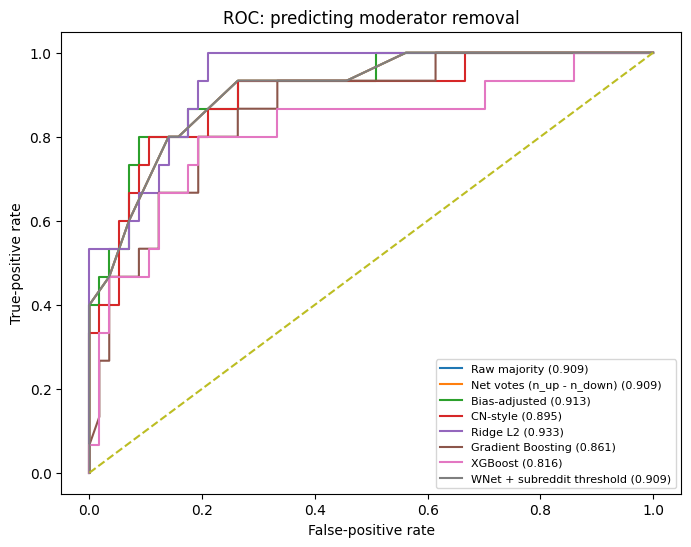

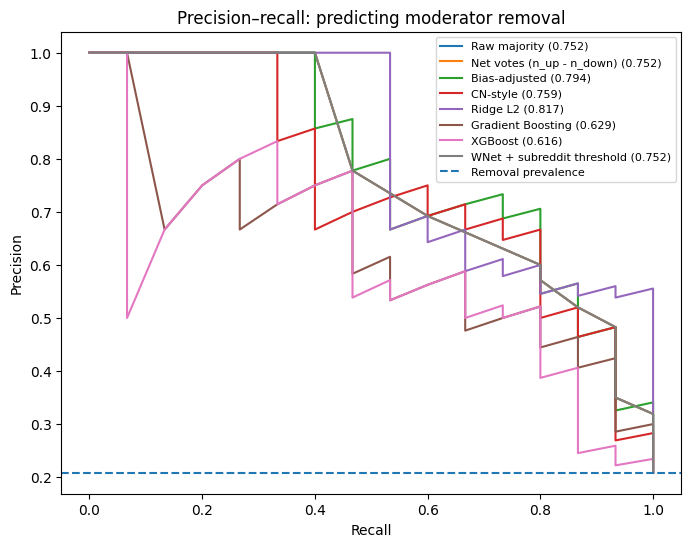

In [16]:
plt.figure(figsize=(8, 6))

for model_name in ALL_MODELS:
    if model_name == "WNet + subreddit threshold":
        score_col = "wnet_remove_score"
    else:
        score_col = SCORE_MODELS[model_name]

    d = test_eval[
        ["removed", score_col]
    ].dropna()

    if d["removed"].nunique() < 2:
        continue

    fpr, tpr, _ = roc_curve(
        d["removed"],
        d[score_col],
    )

    auc = roc_auc_score(
        d["removed"],
        d[score_col],
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} ({auc:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.title("ROC: predicting moderator removal")
plt.legend(fontsize=8)
plt.show()


plt.figure(figsize=(8, 6))

for model_name in ALL_MODELS:
    if model_name == "WNet + subreddit threshold":
        score_col = "wnet_remove_score"
    else:
        score_col = SCORE_MODELS[model_name]

    d = test_eval[
        ["removed", score_col]
    ].dropna()

    if d["removed"].nunique() < 2:
        continue

    precision, recall, _ = precision_recall_curve(
        d["removed"],
        d[score_col],
    )

    ap = average_precision_score(
        d["removed"],
        d[score_col],
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} ({ap:.3f})",
    )

plt.axhline(
    test_eval["removed"].mean(),
    linestyle="--",
    label="Removal prevalence",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–recall: predicting moderator removal")
plt.legend(fontsize=8)
plt.show()

## 17. Confusion matrices for the three supervised models

In [17]:
for model_name in [
    "Ridge L2",
    "Gradient Boosting",
    "XGBoost",
]:
    pred_col = f"pred__{model_name}"

    d = test_eval[
        ["removed", pred_col]
    ].dropna()

    cm = pd.DataFrame(
        confusion_matrix(
            d["removed"],
            d[pred_col].astype(int),
            labels=[0, 1],
        ),
        index=[
            "Actual approved",
            "Actual removed",
        ],
        columns=[
            "Predicted approved",
            "Predicted removed",
        ],
    )

    print(model_name)
    display(cm)

Ridge L2


,Predicted approved,Predicted removed
Actual approved,47,10
Actual removed,3,12


Gradient Boosting


,Predicted approved,Predicted removed
Actual approved,48,9
Actual removed,5,10


XGBoost


,Predicted approved,Predicted removed
Actual approved,47,10
Actual removed,5,10


## 18. Majority vs. CN-style disagreement cells

This preserves the main substantive Community-Notes comparison.

In [18]:
cn_threshold = model_thresholds["CN-style"]

disagree = test_eval.dropna(
    subset=[
        "majority_downvote_share",
        "cn_post_intercept",
    ]
).copy()

disagree["majority_remove"] = (
    disagree["majority_downvote_share"] >= 0.50
)

disagree["cn_remove"] = (
    disagree["cn_post_intercept"] >= cn_threshold
)

conditions = [
    (~disagree["majority_remove"])
    & (~disagree["cn_remove"]),

    disagree["majority_remove"]
    & disagree["cn_remove"],

    disagree["majority_remove"]
    & (~disagree["cn_remove"]),

    (~disagree["majority_remove"])
    & disagree["cn_remove"],
]

labels = [
    "Both approve",
    "Both remove",
    "Majority remove / CN approve",
    "Majority approve / CN remove",
]

disagree["decision_cell"] = np.select(
    conditions,
    labels,
    default="Other",
)

cell_summary = (
    disagree.groupby("decision_cell")
    .agg(
        n_posts=("post_id", "size"),
        moderator_remove_rate=("removed", "mean"),
        mean_downvote_share=(
            "majority_downvote_share",
            "mean",
        ),
        mean_cn_score=(
            "cn_post_intercept",
            "mean",
        ),
    )
    .sort_values("n_posts", ascending=False)
)

display(cell_summary)

,n_posts,moderator_remove_rate,mean_downvote_share,mean_cn_score
decision_cell,,,,
Both approve,32,0.031250,0.319196,-0.155693
Both remove,22,0.545455,0.730519,0.258258
Majority remove / CN approve,18,0.111111,0.535714,0.053117


## 19. Save the main outputs

In [19]:
user_params.to_csv(
    "community_notes_user_viewpoints.csv",
    index=False,
)

train_eval.to_csv(
    "community_notes_train_post_scores.csv",
    index=False,
)

val_eval.to_csv(
    "community_notes_validation_post_scores.csv",
    index=False,
)

test_eval.to_csv(
    "community_notes_test_post_scores.csv",
    index=False,
)

subreddit_thresholds.to_csv(
    "wnet_subreddit_thresholds.csv",
    index=False,
)

remove_performance.reset_index().to_csv(
    "performance_removed_only.csv",
    index=False,
)

approve_performance.reset_index().to_csv(
    "performance_approved_only.csv",
    index=False,
)

combined_performance.reset_index().to_csv(
    "performance_combined.csv",
    index=False,
)

cell_summary.reset_index().to_csv(
    "community_notes_disagreement_cells.csv",
    index=False,
)

print("Saved main output CSVs.")

Saved main output CSVs.


# What to report

The three most useful result tables are:

- `remove_performance` — performance specifically on moderator removals
- `approve_performance` — performance specifically on moderator approvals
- `combined_performance` — overall discrimination and balanced classification performance

For the imbalanced moderator outcome, prioritize:

- **AP for removed posts**
- **recall and precision for removed posts**
- **balanced accuracy**
- **Macro F1**
- **MCC**

The ML models answer a different question from the unsupervised/community-consensus scores: they are explicitly trained on moderator labels, whereas raw voting, bias adjustment, and CN-style scoring are not. Their performance is therefore best interpreted as a supervised upper-comparison rather than as another crowdsourcing rule.